In [2]:
import ruptures as rpt
import numpy as np

def detect_peduncle_boundaries_ruptures(
    vol,
    smooth_win=100,
    area_nonzero_threshold=15,
    model="l2",
    min_size=300,
    pen=100,
    area_ratio_threshold=0.8,
    boundary_margin_slices=50,
    fallback_head_offset=600,
    fallback_tail_offset=900,
    slice_mm=0.084,
    max_len_mm=50.0,
):
    """
    Detect peduncle boundaries using ruptures change-point detection.

    Workflow:
    1. Build per-slice area signal
    2. Detect change points with PELT
    3. Select low-area candidate interval as peduncle
    4. Apply safety margins and max-length cap
    """
    if rpt is None:
        raise ImportError(
            "Ruptures method requires 'ruptures'. Install it with: pip install ruptures"
        )

    mask = vol > 0
    slice_area = mask.sum(axis=(1, 2)).astype(float)
    nz = np.flatnonzero(slice_area > area_nonzero_threshold)
    if nz.size == 0:
        raise RuntimeError("No plant detected.")

    z_top, z_bot = int(nz[0]), int(nz[-1])

    def light_smooth(x, win=10):
        if win <= 1:
            return x.copy()
        k = np.ones(win, float) / win
        return np.convolve(x, k, mode="same")

    area_s = light_smooth(slice_area, win=smooth_win)

    signal = area_s[z_top:z_bot].reshape(-1, 1)
    algo = rpt.Pelt(model=model, min_size=min_size).fit(signal)
    bkps = algo.predict(pen=pen)

    intervals = []
    prev = 0
    for b in bkps:
        start_global = prev + z_top
        end_global = b + z_top
        avg_area = np.mean(area_s[start_global:end_global])
        intervals.append(
            {
                "start": start_global,
                "end": end_global,
                "area": avg_area,
                "len": end_global - start_global,
            }
        )
        prev = b

    global_mean_area = np.mean(area_s[z_top:z_bot])
    candidates = [
        interval
        for interval in intervals
        if interval["area"] < global_mean_area * area_ratio_threshold
    ]

    if not candidates:
        z1 = z_top + fallback_head_offset
        z2 = z_top + fallback_tail_offset
    else:
        candidates.sort(key=lambda x: x['start'])
        best_ped = candidates[0]
        
        if len(candidates) > 1 and best_ped['len'] < 150:
            best_ped = candidates[1]

        z1_raw, z2_raw = best_ped["start"], best_ped["end"]
        z1 = z1_raw + boundary_margin_slices
        z2 = z2_raw - boundary_margin_slices

    max_slices = int(np.ceil(max_len_mm / slice_mm))
    if z2 - z1 > max_slices:
        z2 = z1 + max_slices

    z1 = int(max(z_top, z1))
    z2 = int(min(z_bot, z2))

    if z2 <= z1:
        center = (z_top + z_bot) // 2
        half = max_slices // 2
        z1 = int(max(z_top, center - half))
        z2 = int(min(z_bot, center + half))

    return z1, z2

In [3]:
import tifffile

vol = tifffile.imread("data/0820samples_tif/X-049593.tif")
z1, z2 = detect_peduncle_boundaries_ruptures(
    vol,
    slice_mm=0.084,
    max_len_mm=50.0,
)

Total non-empty slices: 1802


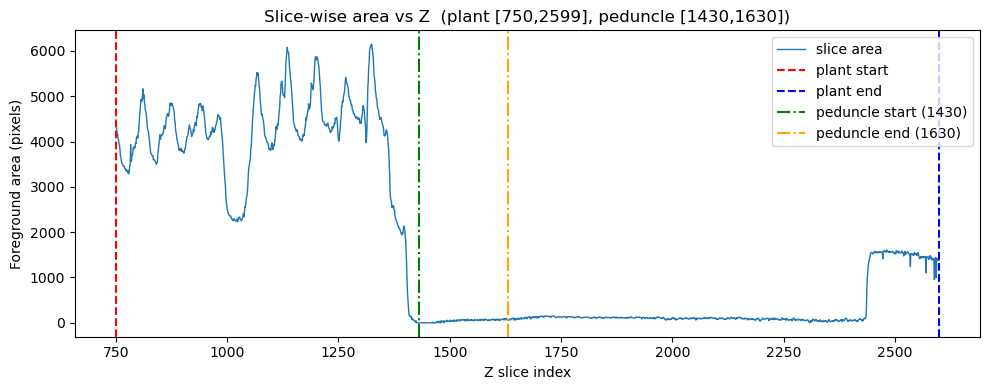

In [4]:
from matplotlib import pyplot as plt
import numpy as np

mask = (vol > 0)

slice_area = mask.sum(axis=(1,2))

print("Total non-empty slices:", int(np.count_nonzero(slice_area)))

nz = np.flatnonzero(slice_area > 0)
z_top, z_bot = (nz[0], nz[-1]) if nz.size else (0, 0)

plt.figure(figsize=(10,4))
plt.plot(np.arange(z_top, z_bot+1), slice_area[z_top:z_bot+1], linewidth=1, label="slice area")

# full plant range
plt.axvline(z_top, linestyle="--", color="red", label="plant start")
plt.axvline(z_bot, linestyle="--", color="blue", label="plant end")

# peduncle range (z1, z2 assumed already defined)
plt.axvline(z1, linestyle="-.", color="green", label=f"peduncle start ({z1})")
plt.axvline(z2, linestyle="-.", color="orange", label=f"peduncle end ({z2})")

plt.xlabel("Z slice index")
plt.ylabel("Foreground area (pixels)")
plt.title(f"Slice-wise area vs Z  (plant [{z_top},{z_bot}], peduncle [{z1},{z2}])")
plt.legend()
plt.tight_layout()
plt.show()